# 02 – EDA lokal (speicherschonend)

**Für ~8 GB RAM** – lädt **nicht** den vollen `train.csv` auf einmal.

| Modus | RAM | Was passiert |
|--------|-----|----------------|
| `sample` | ~100 MB | Nur `train_sample.csv` (10k Zeilen, schnell) |
| `chunked` | ~1–2 GB | Voller Train **chunkweise**, Aggregation pro Region |

❌ **Nicht lokal:** `pd.read_csv(train.csv)` ohne `chunksize` → oft **>4 GB** nur für den DataFrame → Swap / Absturz.

✅ **Colab** für Korrelations-Heatmaps auf allen 1,76 Mio. gelabelten Zeilen.

Outputs: `outputs/regional/region_summary.csv` + Plots in `outputs/figures/`

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config").exists() and (PROJECT_ROOT.parent / "config").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from config.paths import resolve_data_dir, FIGURES_DIR

DATA_DIR = resolve_data_dir()
FIGURES_DIR = FIGURES_DIR
REGIONAL_DIR = PROJECT_ROOT / "outputs" / "regional"
REGIONAL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)

PROJECT_ROOT: /Users/axxtur/Library/Mobile Documents/com~apple~CloudDocs/Uni /Semester 12/Data_Mining_Final/DataMining_Final-Project
DATA_DIR: /Users/axxtur/Library/Mobile Documents/com~apple~CloudDocs/Uni /Semester 12/Data_Mining_Final/DataMining_Final-Project/data


## 1. Modus wählen

- **`sample`**: zum Testen der Zellen (wie `01_exploration`)
- **`chunked`**: echte Regional-Statistik über alle 2.248 Regionen (dauert ~5–15 Min.)

In [2]:
MODE = "chunked"  # "sample" | "chunked"
CHUNK_SIZE = 200_000  # kleiner (= weniger RAM), z.B. 100_000 bei nur 8 GB

SAMPLE_PATH = DATA_DIR / "train_sample.csv"
FULL_TRAIN_PATH = DATA_DIR / "train.csv"

if MODE == "sample":
    TRAIN_PATH = SAMPLE_PATH
    print(f"Modus SAMPLE: {TRAIN_PATH}")
elif MODE == "chunked":
    TRAIN_PATH = FULL_TRAIN_PATH
    print(f"Modus CHUNKED: {TRAIN_PATH} (chunksize={CHUNK_SIZE:,})")
else:
    raise ValueError("MODE must be 'sample' or 'chunked'")

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Missing {TRAIN_PATH} — run: python scripts/create_sample.py")

Modus CHUNKED: /Users/axxtur/Library/Mobile Documents/com~apple~CloudDocs/Uni /Semester 12/Data_Mining_Final/DataMining_Final-Project/data/train.csv (chunksize=200,000)


## 2. Hilfsfunktionen

In [3]:
WEATHER_COLS = [
    "prec", "surf_pre", "humidity", "tmp", "tmp_max", "tmp_min",
    "tmp_range", "wind", "wind_max",
]


def parse_dates(df: pd.DataFrame) -> pd.DataFrame:
    parts = df["date"].astype(str).str.split("-", expand=True)
    df = df.copy()
    df["year"] = parts[0].astype(int)
    df["month"] = parts[1].astype(int)
    df["day"] = parts[2].astype(int)
    return df


def iter_chunks(path: Path, chunksize: int):
    return pd.read_csv(path, chunksize=chunksize)


def update_region_stats(acc: dict, chunk: pd.DataFrame) -> None:
    """Running aggregates per region_id (memory-safe)."""
    for region, g in chunk.groupby("region_id", sort=False):
        if region not in acc:
            acc[region] = {
                "n_rows": 0,
                "n_scored": 0,
                "score_sum": 0.0,
                "year_min": 10**9,
                "year_max": -1,
                **{f"{c}_sum": 0.0 for c in WEATHER_COLS},
            }
        s = acc[region]
        n = len(g)
        s["n_rows"] += n
        scored = g["score"].notna()
        s["n_scored"] += int(scored.sum())
        if scored.any():
            s["score_sum"] += float(g.loc[scored, "score"].sum())
        if "year" in g.columns:
            s["year_min"] = min(s["year_min"], int(g["year"].min()))
            s["year_max"] = max(s["year_max"], int(g["year"].max()))
        for c in WEATHER_COLS:
            s[f"{c}_sum"] += float(g[c].sum())


def acc_to_dataframe(acc: dict) -> pd.DataFrame:
    rows = []
    for region, s in acc.items():
        n = s["n_rows"]
        row = {
            "region_id": region,
            "n_rows": n,
            "n_scored": s["n_scored"],
            "score_rate": s["n_scored"] / n if n else 0,
            "score_mean": s["score_sum"] / s["n_scored"] if s["n_scored"] else np.nan,
            "year_min": s["year_min"],
            "year_max": s["year_max"],
        }
        for c in WEATHER_COLS:
            row[f"{c}_mean"] = s[f"{c}_sum"] / n if n else np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values("region_id").reset_index(drop=True)

## 3. Chunked Regional-Aggregation (alle Regionen)

Ein Durchlauf über die Datei – nur Dictionary im RAM, kein voller DataFrame.

In [4]:
region_acc = {}

labeled_parts = []

LABELED_SAMPLE_TARGET = 30_000

labeled_count = 0



if MODE == "sample":

    df = parse_dates(pd.read_csv(TRAIN_PATH))

    update_region_stats(region_acc, df)

    labeled = df[df["score"].notna()]

    if len(labeled):

        labeled_parts.append(labeled)

    print(f"Sample geladen: {len(df):,} Zeilen, {df['region_id'].nunique()} Regionen")

else:

    from tqdm.auto import tqdm

    reader = iter_chunks(TRAIN_PATH, CHUNK_SIZE)

    for i, chunk in enumerate(tqdm(reader, desc="Chunks")):

        chunk = parse_dates(chunk)

        update_region_stats(region_acc, chunk)

        scored = chunk[chunk["score"].notna()]

        if len(scored) and labeled_count < LABELED_SAMPLE_TARGET:

            need = LABELED_SAMPLE_TARGET - labeled_count

            take = scored if len(scored) <= need else scored.sample(need, random_state=42)

            labeled_parts.append(take)

            labeled_count += len(take)

    print(f"Fertig. Regionen: {len(region_acc):,}, gelabelte Stichprobe: {labeled_count:,}")



region_summary = acc_to_dataframe(region_acc)

out_csv = REGIONAL_DIR / "region_summary.csv"

region_summary.to_csv(out_csv, index=False)

print(f"Gespeichert: {out_csv}")

region_summary.head(10)



/Users/axxtur/Library/Mobile Documents/com~apple~CloudDocs/Uni /Semester 12/Data_Mining_Final/DataMining_Final-Project/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Chunks: 62it [02:08,  2.08s/it]

Fertig. Regionen: 2,248, gelabelte Stichprobe: 30,000
Gespeichert: /Users/axxtur/Library/Mobile Documents/com~apple~CloudDocs/Uni /Semester 12/Data_Mining_Final/DataMining_Final-Project/outputs/regional/region_summary.csv


,region_id,n_rows,n_scored,score_rate,score_mean,year_min,year_max,prec_mean,surf_pre_mean,humidity_mean,tmp_mean,tmp_max_mean,tmp_min_mean,tmp_range_mean,wind_mean,wind_max_mean
0,R1,5480,782,0.142701,0.997442,3004,3019,3.743161,100.276217,10.480308,17.657434,23.943442,11.976728,11.966688,2.062456,2.944995
1,R1001,5480,782,0.142701,0.525575,23086,23101,3.415005,100.213199,9.109013,14.541741,19.976255,9.315529,10.660726,3.849599,5.670412
2,R1002,5480,782,0.142701,0.369565,23088,23103,3.834228,99.372538,8.903489,13.736934,19.147243,8.535513,10.611710,3.054060,4.482308
3,R1005,5480,782,0.142701,0.374680,23094,23109,3.633111,99.826765,8.748299,13.524286,19.004285,8.306633,10.697684,3.000363,4.356206
4,R1006,5480,782,0.142701,0.341432,23096,23111,3.685998,99.240493,8.656956,13.396573,18.773491,8.198239,10.575299,3.118703,4.550447
5,R1007,5480,782,0.142701,0.476982,23098,23113,3.214735,96.018600,8.369234,13.047175,18.965265,7.628796,11.336531,1.977016,2.844650
6,R1009,5480,782,0.142701,0.391304,23102,23117,3.797358,99.064710,8.848706,13.699947,19.063137,8.503974,10.559131,3.082223,4.513016
7,R1011,5480,782,0.142701,0.341432,23106,23121,3.483666,99.054281,8.450429,12.844296,18.243500,7.617482,10.626033,3.047431,4.432380
8,R1012,5480,782,0.142701,0.543478,23108,23123,3.415005,100.213199,9.109013,14.541741,19.976255,9.315529,10.660726,3.849599,5.670412
9,R1014,5480,782,0.142701,0.410486,23112,23127,3.436299,97.763779,8.543580,13.304478,18.966661,7.987823,10.978934,2.358102,3.396088


## 4. Plots aus Regional-Summary (wenig RAM)

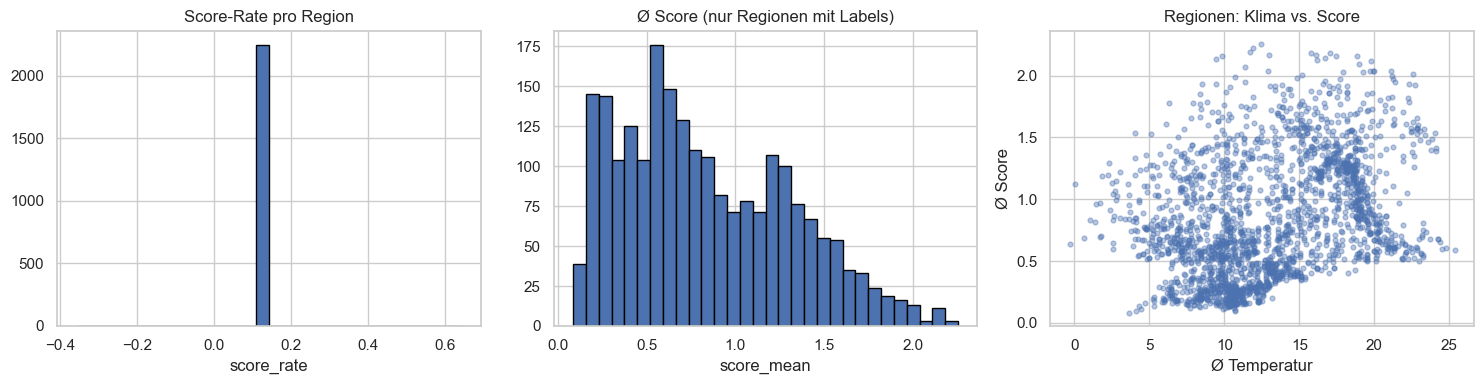

       n_rows  n_scored   score_rate
count  2248.0    2248.0  2248.000000
mean   5480.0     782.0     0.142701
std       0.0       0.0     0.000000
min    5480.0     782.0     0.142701
25%    5480.0     782.0     0.142701
50%    5480.0     782.0     0.142701
75%    5480.0     782.0     0.142701
max    5480.0     782.0     0.142701


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(region_summary["score_rate"], bins=30, edgecolor="black")
axes[0].set_title("Score-Rate pro Region")
axes[0].set_xlabel("score_rate")

axes[1].hist(region_summary["score_mean"].dropna(), bins=30, edgecolor="black")
axes[1].set_title("Ø Score (nur Regionen mit Labels)")
axes[1].set_xlabel("score_mean")

axes[2].scatter(region_summary["tmp_mean"], region_summary["score_mean"], alpha=0.4, s=12)
axes[2].set_xlabel("Ø Temperatur")
axes[2].set_ylabel("Ø Score")
axes[2].set_title("Regionen: Klima vs. Score")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "local_regional_overview.png", dpi=120, bbox_inches="tight")
plt.show()

print(region_summary[["n_rows", "n_scored", "score_rate"]].describe())

## 5. Korrelation (Stichprobe gelabelter Zeilen)

Nur ~30k gelabelte Zeilen – Schätzung der globalen Korrelation, passt in 8 GB.

Top Korrelationen mit score (Stichprobe gelabelter Zeilen):


,corr
tmp_range,0.169542
tmp_max,0.159826
surf_tmp,0.129928
tmp,0.127172
month,0.126039
tmp_min,0.094725
surf_pre,-0.086994
year,0.054978
wind_range,0.032720
wind_min,-0.032332


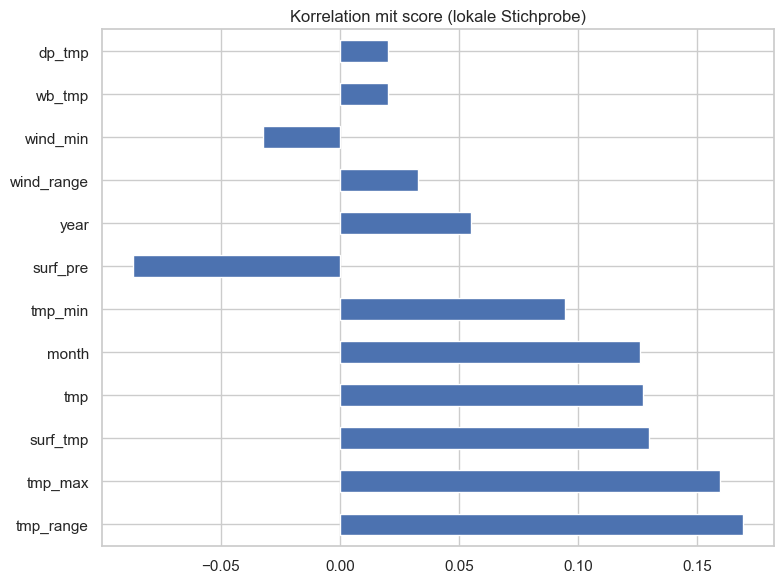

In [6]:
if labeled_parts:
    df_labeled = pd.concat(labeled_parts, ignore_index=True)
    num = df_labeled.select_dtypes(include=[np.number])
    if "score" in num.columns:
        corr = num.corr()["score"].drop("score").sort_values(key=abs, ascending=False)
        print("Top Korrelationen mit score (Stichprobe gelabelter Zeilen):")
        display(corr.head(15).to_frame("corr"))
        fig, ax = plt.subplots(figsize=(8, 6))
        corr.head(12).plot(kind="barh", ax=ax)
        ax.set_title("Korrelation mit score (lokale Stichprobe)")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "local_score_corr_sample.png", dpi=120, bbox_inches="tight")
        plt.show()
else:
    print("Keine gelabelten Zeilen in der Stichprobe.")

## 6. Einzelregionen im Detail (optional)

Lädt **eine Region nach der other** aus dem Train (max. ~5.480 Zeilen ≈ wenig RAM).

Detail-Plots: R1714 (hoher Ø-Score) vs R1145 (niedriger Ø-Score)


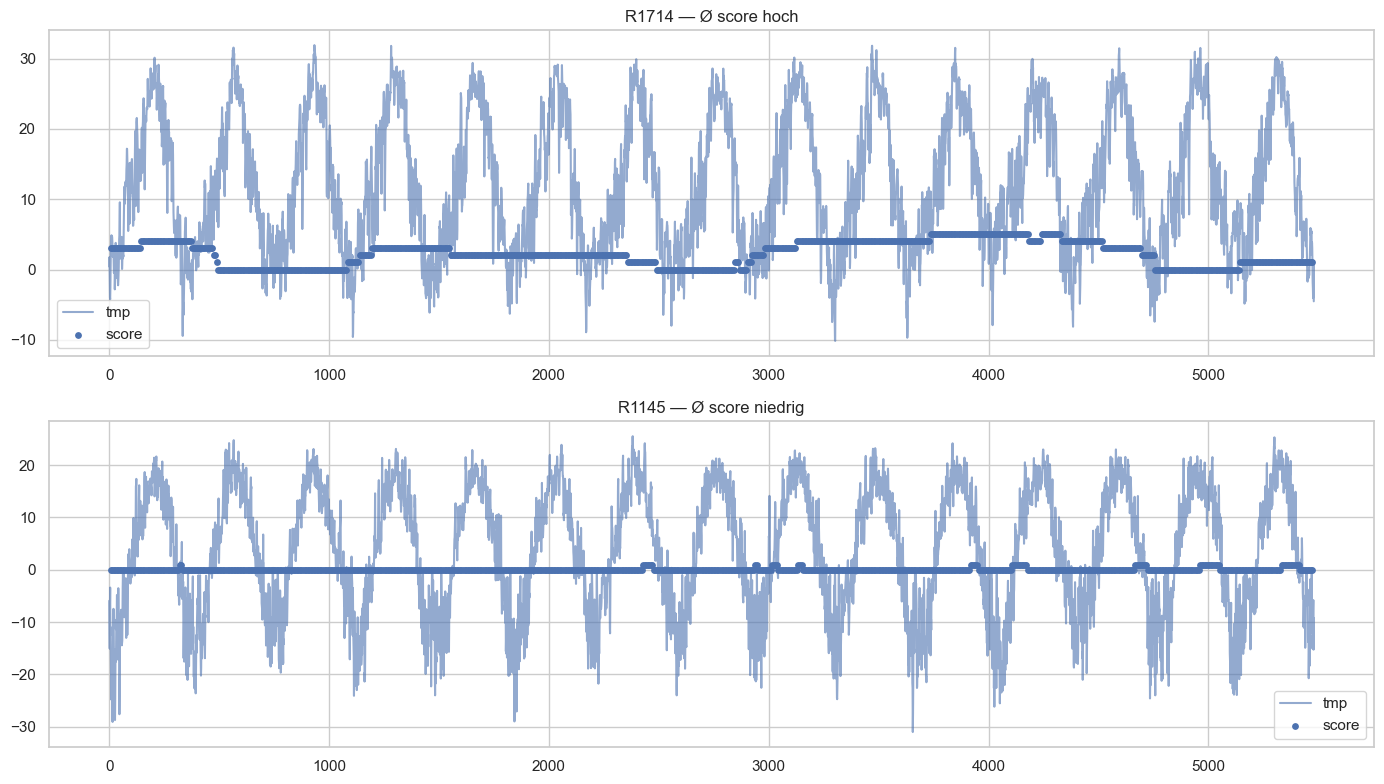

In [7]:
def load_one_region(path: Path, region_id: str, chunksize: int = 200_000) -> pd.DataFrame:
    parts = []
    for chunk in pd.read_csv(path, chunksize=chunksize):
        sub = chunk[chunk["region_id"] == region_id]
        if len(sub):
            parts.append(sub)
    if not parts:
        return pd.DataFrame()
    return parse_dates(pd.concat(parts, ignore_index=True))


# Beispiel: Region mit hohem vs. niedrigem Ø-Score
valid = region_summary.dropna(subset=["score_mean"])
if len(valid) >= 2:
    high_r = valid.loc[valid["score_mean"].idxmax(), "region_id"]
    low_r = valid.loc[valid["score_mean"].idxmin(), "region_id"]
    print(f"Detail-Plots: {high_r} (hoher Ø-Score) vs {low_r} (niedriger Ø-Score)")

    path = TRAIN_PATH if MODE == "sample" else FULL_TRAIN_PATH
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
    for ax, rid, title in zip(axes, [high_r, low_r], ["hoch", "niedrig"]):
        if MODE == "sample":
            rdf = df[df["region_id"] == rid].sort_values(["year", "month", "day"])
        else:
            rdf = load_one_region(path, rid, CHUNK_SIZE)
            rdf = rdf.sort_values(["year", "month", "day"])
        ax.plot(rdf["tmp"].values, alpha=0.6, label="tmp")
        scored = rdf["score"].notna()
        if scored.any():
            ax.scatter(np.where(scored)[0], rdf.loc[scored, "score"], s=15, label="score")
        ax.set_title(f"{rid} — Ø score {title}")
        ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "local_region_compare.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("Zu wenig Regionen in summary für Vergleich.")

## 7. Regional-Batches (optional, für viele Detail-Plots)

Verarbeitet Regionen in Gruppen à `BATCH_SIZE` – speichert pro Batch nur Mittelwerte, keine Rohzeitreihen.

In [8]:
RUN_BATCH_LOOP = False  # True nur wenn gewünscht (zusätzlicher Datei-Durchlauf)
BATCH_SIZE = 100

if RUN_BATCH_LOOP and MODE == "chunked":
    all_regions = sorted(region_summary["region_id"].unique())
    batch_rows = []
    for b in range(0, len(all_regions), BATCH_SIZE):
        batch_ids = set(all_regions[b : b + BATCH_SIZE])
        acc = {}
        for chunk in iter_chunks(FULL_TRAIN_PATH, CHUNK_SIZE):
            chunk = parse_dates(chunk)
            sub = chunk[chunk["region_id"].isin(batch_ids)]
            if len(sub):
                update_region_stats(acc, sub)
        batch_rows.append(acc_to_dataframe(acc))
        print(f"Batch {b // BATCH_SIZE + 1} done ({len(batch_ids)} regions)")
    print("Batch loop finished.")
else:
    print("Batch-Loop übersprungen (RUN_BATCH_LOOP=False oder MODE=sample).")

Batch-Loop übersprungen (RUN_BATCH_LOOP=False oder MODE=sample).


## 8. Fazit lokal

- **`region_summary.csv`** → alle Regionen, für Team & Plots
- **8 GB:** `MODE="chunked"` + `CHUNK_SIZE=100_000` ist OK; kein volles `read_csv`
- **Exakte** Korrelation / Heatmap auf allen Labels → Colab (`01_exploration`)

Ergebnisse in `docs/04_TRAIN_DATA_ANALYSIS.md` eintragen, wenn Vollbild-Chunk abweicht.